In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from lightgbm import LGBMClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/DATASET 2.csv')
# Separate labels (target column)



In [ ]:
df1

,FV1,FV2,FV3,FV4,FV5,FV6,FV7,FV8,FV9,FV10,...,FV513,FV514,FV515,FV516,FV517,FV518,FV519,FV520,FV521,CLASS-LABEL
0,9435.0,390011,21403639.0,1.322124e+09,388114.0,16089200.0,8.836494e+08,21059404.0,8.743913e+08,1.283313e+09,...,22238.0,23030.0,50479.0,58601.0,19065.0,44827.0,79167.0,68540.0,49574.0,0.0
1,7382.0,269056,12907222.0,6.947767e+08,262408.0,9636989.0,4.641328e+08,12306114.0,4.537181e+08,6.486750e+08,...,41690.0,28192.0,36238.0,53363.0,41552.0,31806.0,47496.0,24026.0,29215.0,0.0
2,12871.0,614235,38863801.0,2.766000e+09,612976.0,29255000.0,1.849606e+09,38602014.0,1.840405e+09,2.723398e+09,...,49066.0,22466.0,82149.0,74143.0,94185.0,147367.0,125748.0,74583.0,89820.0,0.0
3,13324.0,648284,41945426.0,3.050727e+09,655880.0,31797144.0,2.053901e+09,42577616.0,2.055764e+09,3.093700e+09,...,88021.0,65942.0,69451.0,115216.0,87660.0,115527.0,132444.0,61908.0,86592.0,0.0
4,8469.0,324438,16479440.0,9.419279e+08,323017.0,12380699.0,6.280145e+08,16494219.0,6.314446e+08,9.494133e+08,...,23949.0,5200.0,41667.0,96021.0,27451.0,71207.0,28045.0,28860.0,23865.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49037,326.0,2889,32787.0,4.179570e+05,2765.0,24065.0,2.700550e+05,31795.0,2.738050e+05,4.150130e+05,...,137.0,0.0,63.0,123.0,0.0,20.0,197.0,169.0,104.0,3.0
49038,307.0,2464,26108.0,3.151120e+05,2445.0,18894.0,1.978640e+05,24757.0,1.891440e+05,2.796690e+05,...,22.0,0.0,4.0,140.0,0.0,110.0,460.0,78.0,36.0,3.0
49039,980.0,16114,341026.0,8.058316e+06,14106.0,231269.0,4.880535e+06,272438.0,4.443689e+06,5.991174e+06,...,0.0,267.0,118.0,1528.0,40.0,369.0,1690.0,913.0,554.0,3.0
49040,2667.0,62303,1929959.0,6.715919e+07,59516.0,1384339.0,4.256264e+07,1764106.0,4.112920e+07,5.889945e+07,...,616.0,879.0,2686.0,4925.0,1225.0,4759.0,16804.0,8018.0,6835.0,3.0


In [ ]:
feature = df1.iloc[:, :-1].values.astype(float)
labels = df1.iloc[:, -1].values.astype(int)


/tmp/ipython-input-4260555403.py:2: RuntimeWarning: invalid value encountered in cast
  labels = df1.iloc[:, -1].values.astype(int)


In [ ]:
df1

**Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
feature = feature.apply(le.fit_transform)


AttributeError: 'numpy.ndarray' object has no attribute 'apply'

In [ ]:
#feature.replace([np.inf, -np.inf],np.nan,inplace=True)
#feature=np.nan_to_num( feature)
#labels=np.nan_to_num( labels)


**SMOTE SAMPLING**

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE()

feature_res, labels_res = smote.fit_resample(feature, labels)



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(feature)

**Standard Scaler For Features Scaling**

In [ ]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 97.42%

Confusion Matrix:
 [[33431     1     0   409]
 [   30  2874     0    32]
 [    0     0   312     0]
 [  774    18     0 11160]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     33841
           1       0.99      0.98      0.99      2936
           2       1.00      1.00      1.00       312
           3       0.96      0.93      0.95     11952

    accuracy                           0.97     49041
   macro avg       0.98      0.98      0.98     49041
weighted avg       0.97      0.97      0.97     49041


MCC ---> 0.9438


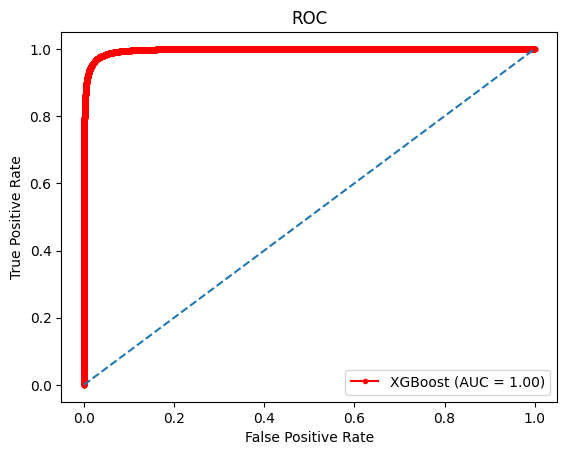

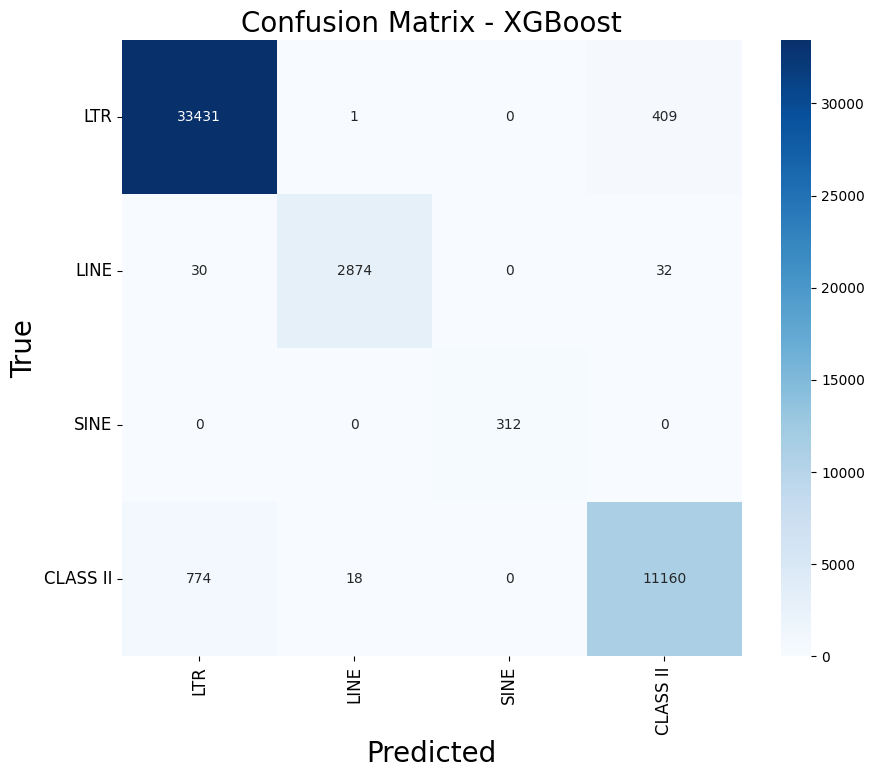

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 4

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.482461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127921
[LightGBM] [Info] Number of data points in the train set: 49041, number of used features: 516
[LightGBM] [Info] Start training from score -0.370984
[LightGBM] [Info] Start training from score -2.815609
[LightGBM] [Info] Start training from score -5.057409
[LightGBM] [Info] Start training from score -1.411758
Self-Consistency Accuracy: 93.21%

Confusion Matrix:
 [[32760    29     0  1052]
 [   92  2703     0   141]
 [    0     0   312     0]
 [ 1937    77     0  9938]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95     33841
           1       0.96      0.92      0.94      2936
           2       1.00      1.00      1.00       312
           3       0.89      0.83      0.86     11952

    accuracy                    

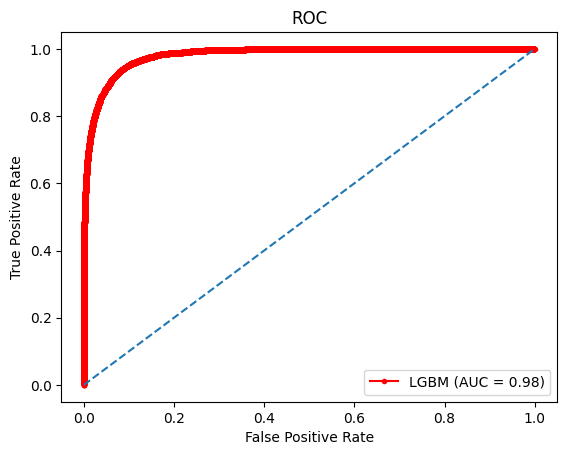

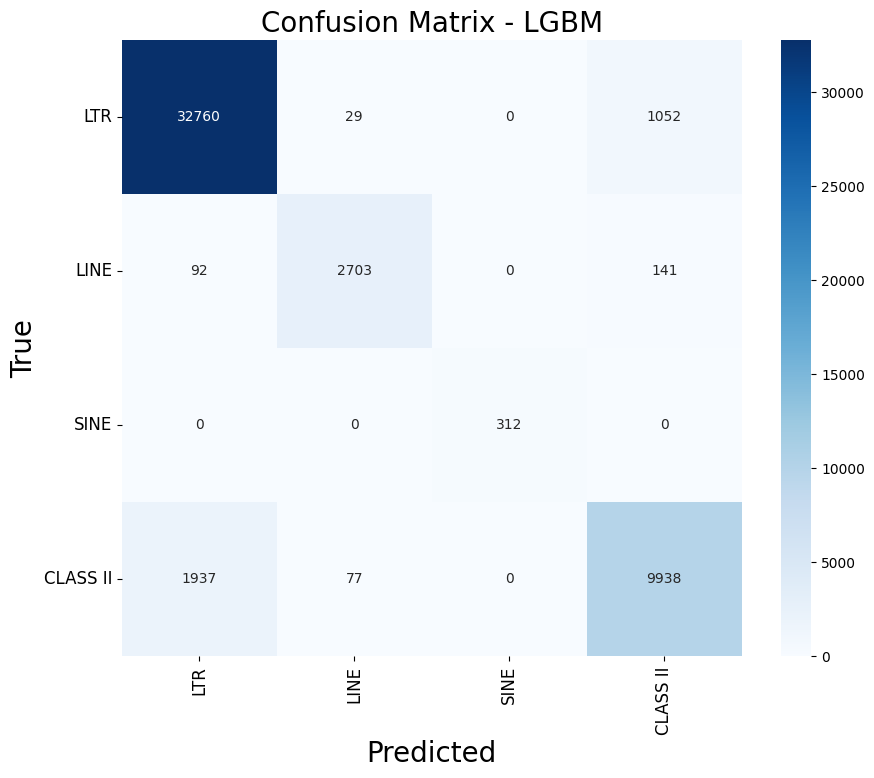

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)


# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 4

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.31%

Confusion Matrix:
 [[33815     0     1    25]
 [   71  2857     0     8]
 [    0     3   305     4]
 [  224     1     1 11726]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     33841
           1       1.00      0.97      0.99      2936
           2       0.99      0.98      0.99       312
           3       1.00      0.98      0.99     11952

    accuracy                           0.99     49041
   macro avg       1.00      0.98      0.99     49041
weighted avg       0.99      0.99      0.99     49041


MCC ---> 0.9850


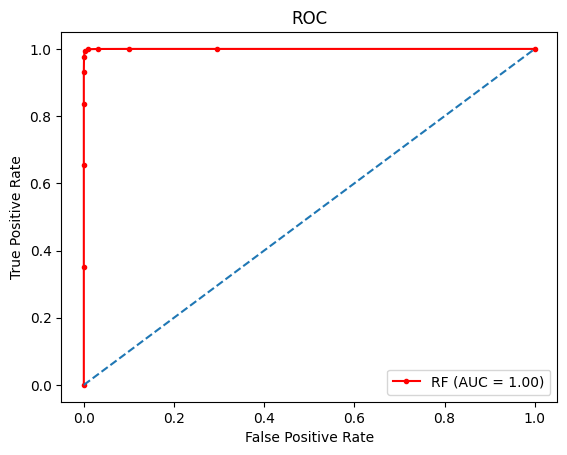

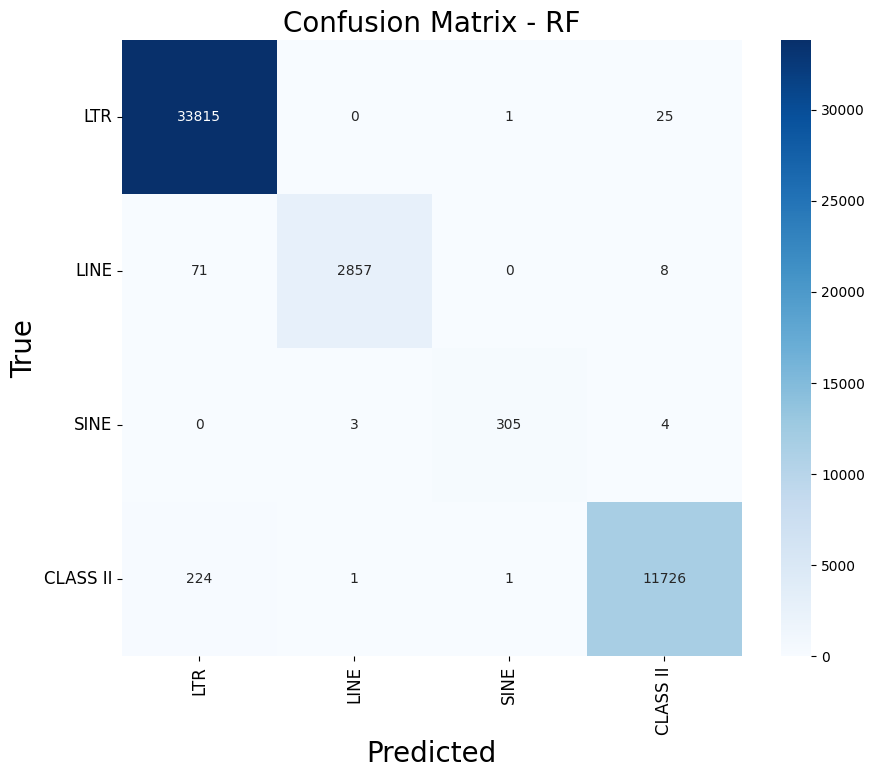

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 4

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 100.00%

Confusion Matrix:
 [[33841     0     0     0]
 [    0  2936     0     0]
 [    0     0   312     0]
 [    0     0     0 11952]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     33841
           1       1.00      1.00      1.00      2936
           2       1.00      1.00      1.00       312
           3       1.00      1.00      1.00     11952

    accuracy                           1.00     49041
   macro avg       1.00      1.00      1.00     49041
weighted avg       1.00      1.00      1.00     49041


MCC ---> 1.0000


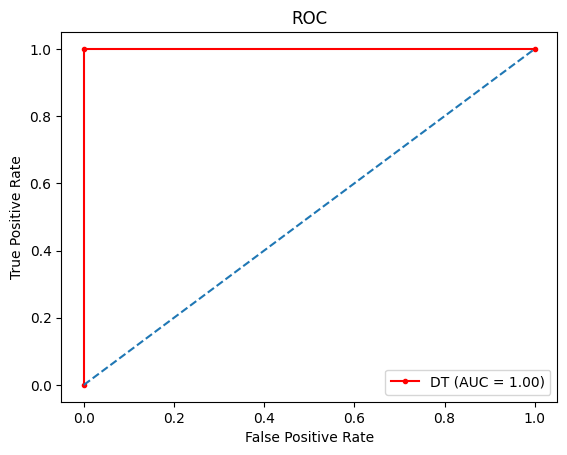

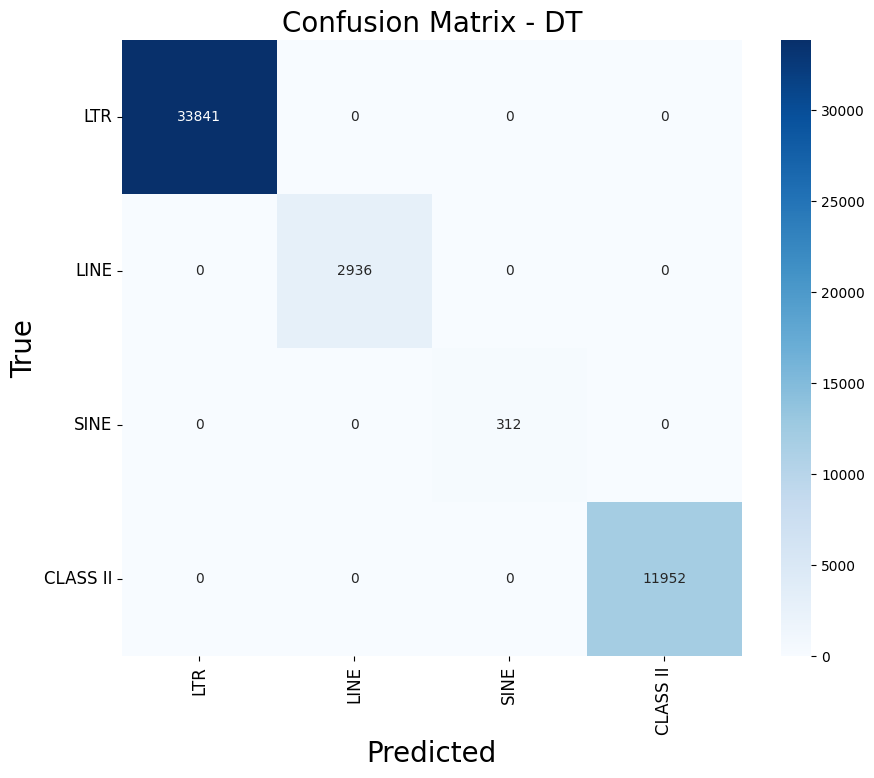

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 4

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['LTR','LINE','SINE','CLASS II']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


# **ROC-SELF TEST**

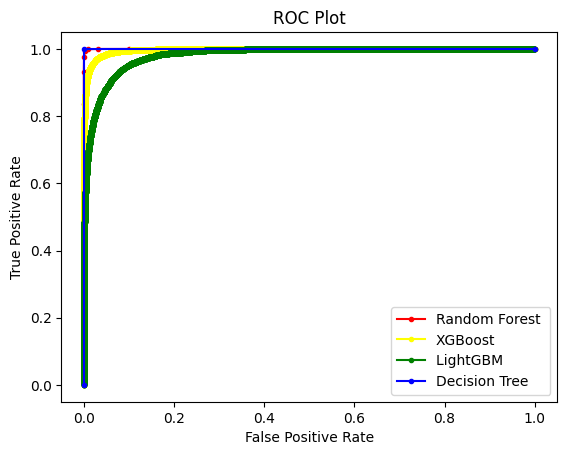

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


#  **Independent Set Testing (Train Test Split)**    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(feature_res , labels_res, test_size=0.3, random_state=100,stratify=labels_res)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(94754, 521) (40610, 521)
(94754,) (40610,)


Training accuracy is 0.986976803090107
Test accuracy is 0.9561684314208323
[[ 9166   110     0   877]
 [   22 10082     1    47]
 [    0     0 10152     0]
 [  541   166    16  9430]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     10153
           1       0.97      0.99      0.98     10152
           2       1.00      1.00      1.00     10152
           3       0.91      0.93      0.92     10153

    accuracy                           0.96     40610
   macro avg       0.96      0.96      0.96     40610
weighted avg       0.96      0.96      0.96     40610

Accuracy 95.62%
MCC ---> 0.9416580003131385
Sensitivity :  0.988141440275981
Specificity :  0.9978226444972288


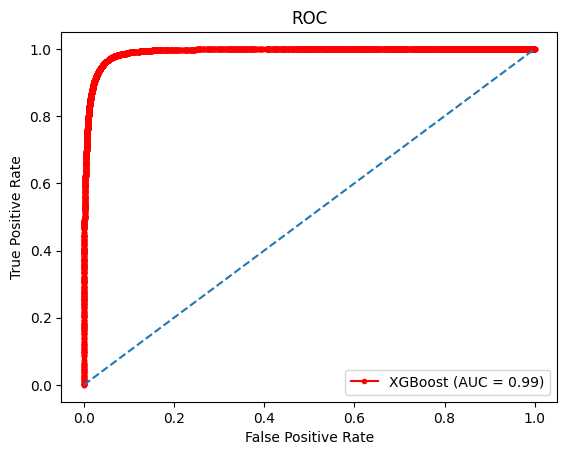

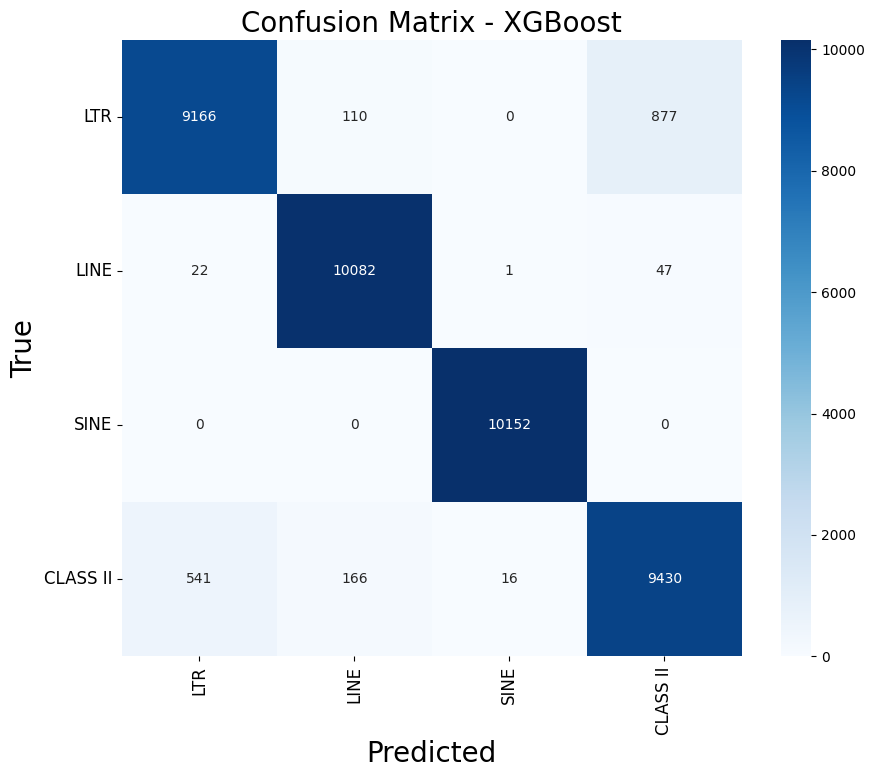

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 4

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels =['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9985119361715601
Test accuracy is 0.9492243289830091
[[ 9251   171     2   729]
 [   89 10023    13    27]
 [    2     5 10144     1]
 [  773   213    37  9130]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     10153
           1       0.96      0.99      0.97     10152
           2       0.99      1.00      1.00     10152
           3       0.92      0.90      0.91     10153

    accuracy                           0.95     40610
   macro avg       0.95      0.95      0.95     40610
weighted avg       0.95      0.95      0.95     40610

Accuracy 94.92%
MCC ---> 0.9323525433025869
Sensitivity :  0.9818509870515814
Specificity :  0.9911985759493671


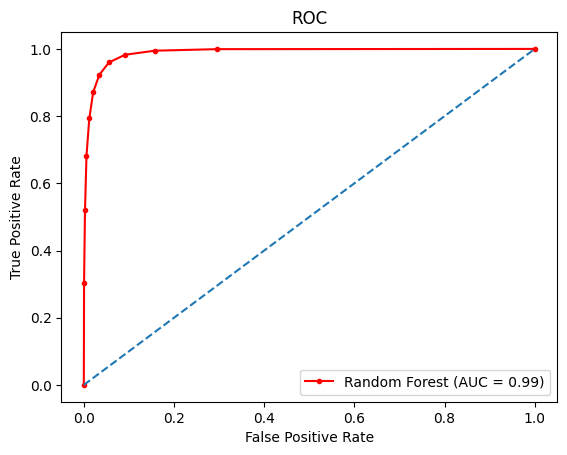

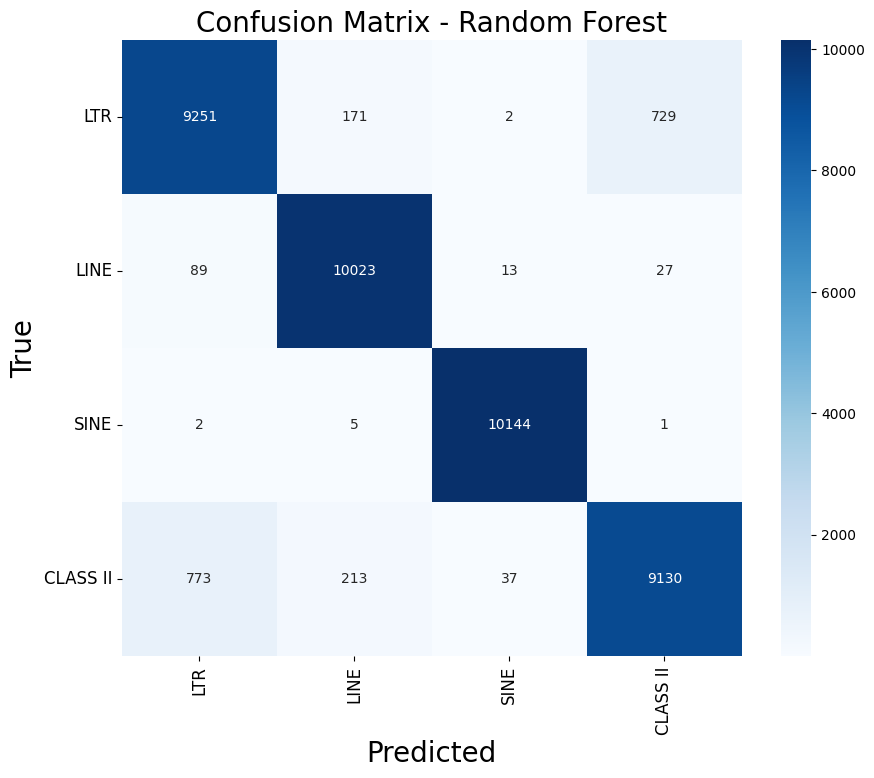

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 4
for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 1.0
Test accuracy is 0.9111548879586309
[[ 8586   336     6  1225]
 [  214  9579    74   285]
 [    5    28 10079    40]
 [  963   366    66  8758]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.86     10153
           1       0.93      0.94      0.94     10152
           2       0.99      0.99      0.99     10152
           3       0.85      0.86      0.86     10153

    accuracy                           0.91     40610
   macro avg       0.91      0.91      0.91     40610
weighted avg       0.91      0.91      0.91     40610

Accuracy 91.12%
MCC ---> 0.8816119466235414
Sensitivity :  0.9623402824478816
Specificity :  0.9781476564893291


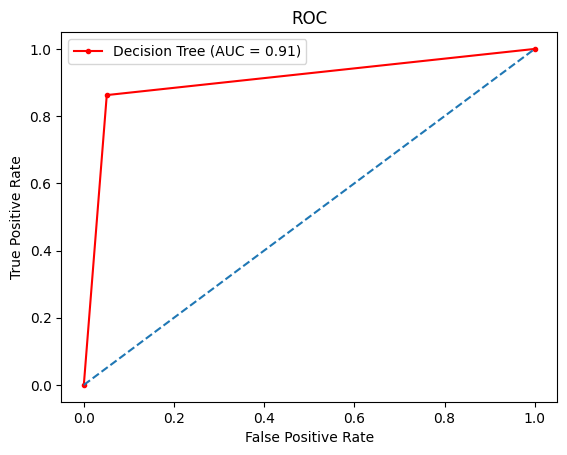

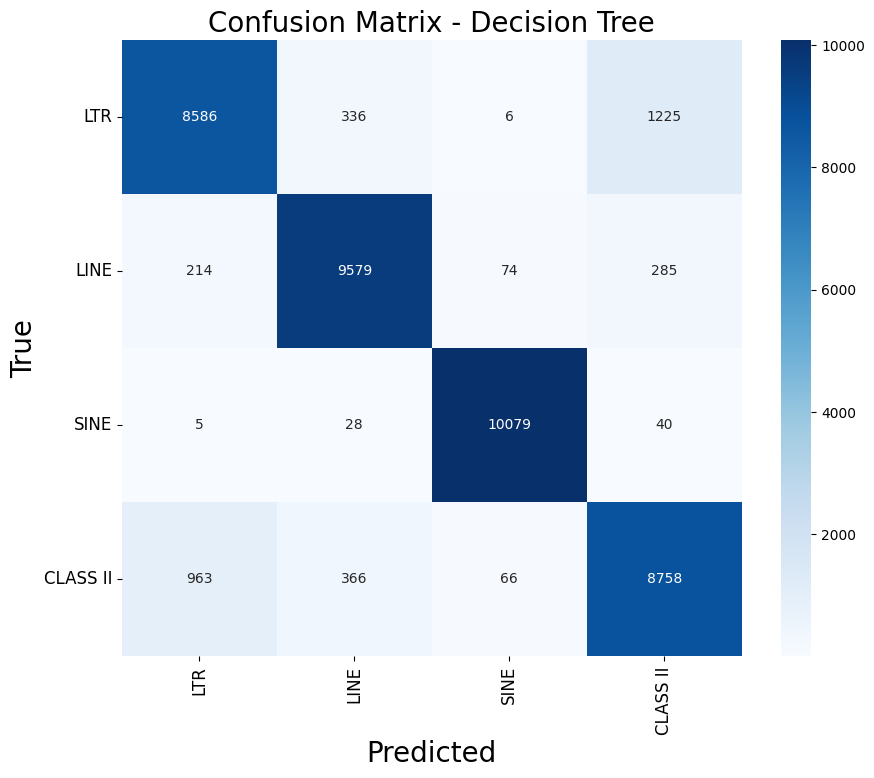

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 4

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.644820 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127547
[LightGBM] [Info] Number of data points in the train set: 94754, number of used features: 516
[LightGBM] [Info] Start training from score -1.386315
[LightGBM] [Info] Start training from score -1.386273
[LightGBM] [Info] Start training from score -1.386273
[LightGBM] [Info] Start training from score -1.386315


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training accuracy is 0.9610148384237077


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test accuracy is 0.9414676188131003


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[ 8966   126     0  1061]
 [   60  9979     9   104]
 [    0     0 10152     0]
 [  719   266    32  9136]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     10153
           1       0.96      0.98      0.97     10152
           2       1.00      1.00      1.00     10152
           3       0.89      0.90      0.89     10153

    accuracy                           0.94     40610
   macro avg       0.94      0.94      0.94     40610
weighted avg       0.94      0.94      0.94     40610

Accuracy 94.15%
MCC ---> 0.922045559286489
Sensitivity :  0.9861416630004399
Specificity :  0.9940233090945313


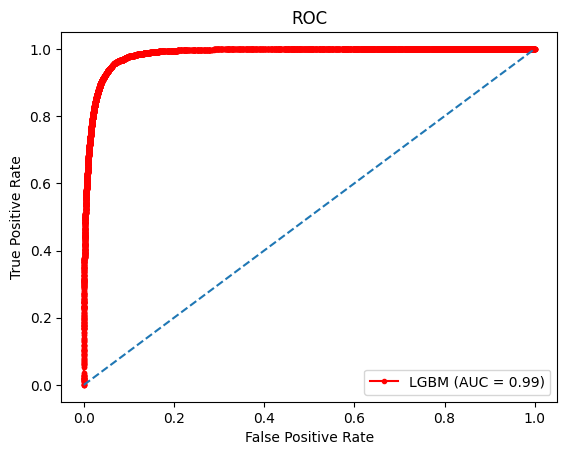

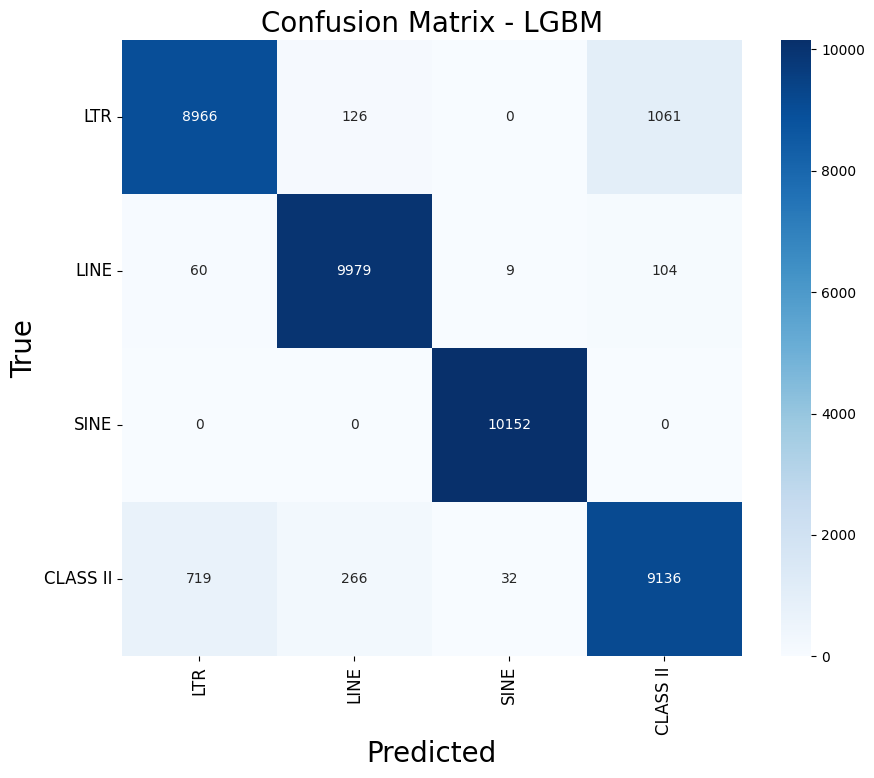

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 4

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['LTR','LINE','SINE','CLASS II']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

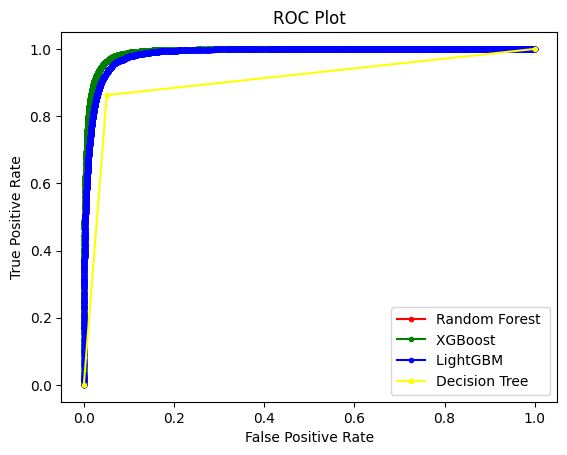

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Mean of Accuracies:  81.23823195361126
[[31798   332     2  1709]
 [  978  1432    50   476]
 [    6    71   123   112]
 [ 4919   459    87  6487]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     33841
           1       0.62      0.49      0.55      2936
           2       0.47      0.39      0.43       312
           3       0.74      0.54      0.63     11952

    accuracy                           0.81     49041
   macro avg       0.67      0.59      0.62     49041
weighted avg       0.80      0.81      0.80     49041

Accuracy 81.24%
MCC ---> 0.5665174332926679
Sensitivity :  0.989666977902272
Specificity :  0.5941908713692946


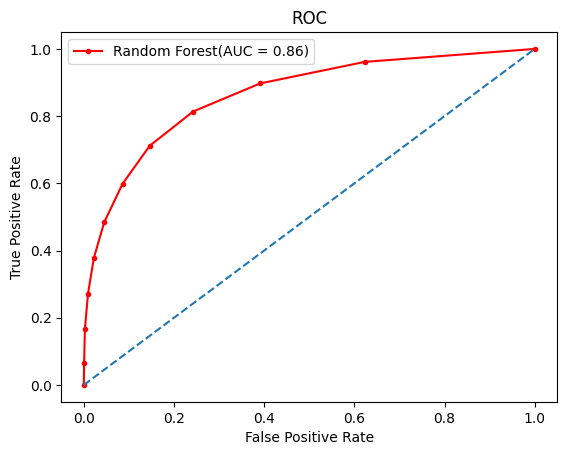

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------
# Cross-validation setup
# -------------------------------
n_splits = 10
n_classes = 4   # number of TE orders

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------
# Storage for statistical tests
# -------------------------------
rf_order_acc = []
rf_order_mcc = []
rf_order_sen = []
rf_order_spe = []

# For ROC (combined plot later)
rf_order_fpr = dict()
rf_order_tpr = dict()
rf_order_auc = dict()

# -------------------------------
# Cross-validation loop
# -------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model = RandomForestClassifier(
        n_estimators=10,
        random_state=10
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # ---------------------------
    # Accuracy
    # ---------------------------
    rf_order_acc.append(
        accuracy_score(y_test, y_pred)
    )

    # ---------------------------
    # MCC (multiclass)
    # ---------------------------
    rf_order_mcc.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # ---------------------------
    # Sensitivity (macro recall)
    # ---------------------------
    rf_order_sen.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # ---------------------------
    # Specificity (macro)
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))

    rf_order_spe.append(
        np.mean(specificity_per_class)
    )

    # ---------------------------
    # ROC (One-vs-Rest)
    # ---------------------------
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr = dict()
    tpr = dict()
    auc_scores = []

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_scores.append(auc(fpr[i], tpr[i]))

    rf_order_fpr[fold] = fpr
    rf_order_tpr[fold] = tpr
    rf_order_auc[fold] = np.mean(auc_scores)

# -------------------------------
# Print CV summary (Mean ± Std)
# -------------------------------
print("10-Fold Cross-Validation Results (TE Order Classification)")
print(f"Accuracy    : {np.mean(rf_order_acc):.3f} ± {np.std(rf_order_acc, ddof=1):.3f}")
print(f"MCC         : {np.mean(rf_order_mcc):.3f} ± {np.std(rf_order_mcc, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(rf_order_sen):.3f} ± {np.std(rf_order_sen, ddof=1):.3f}")
print(f"Specificity : {np.mean(rf_order_spe):.3f} ± {np.std(rf_order_spe, ddof=1):.3f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------
# Cross-validation setup
# -------------------------------
n_splits = 10
n_classes = 4   # number of TE orders

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------
# Storage for statistical tests
# -------------------------------
xgb_order_acc = []
xgb_order_mcc = []
xgb_order_sen = []
xgb_order_spe = []

# For ROC (combined plot later)
xgb_order_fpr = dict()
xgb_order_tpr = dict()
xgb_order_auc = dict()

# -------------------------------
# Cross-validation loop
# -------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model = XGBClassifier(
        n_estimators=100,
        objective='multi:softprob',
        num_class=n_classes,
        eval_metric='mlogloss',
        random_state=42,
        use_label_encoder=False
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # ---------------------------
    # Accuracy
    # ---------------------------
    xgb_order_acc.append(
        accuracy_score(y_test, y_pred)
    )

    # ---------------------------
    # MCC (multiclass)
    # ---------------------------
    xgb_order_mcc.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # ---------------------------
    # Sensitivity (macro recall)
    # ---------------------------
    xgb_order_sen.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # ---------------------------
    # Specificity (macro)
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))

    xgb_order_spe.append(
        np.mean(specificity_per_class)
    )

    # ---------------------------
    # ROC (One-vs-Rest)
    # ---------------------------
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr = dict()
    tpr = dict()
    auc_scores = []

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_scores.append(auc(fpr[i], tpr[i]))

    xgb_order_fpr[fold] = fpr
    xgb_order_tpr[fold] = tpr
    xgb_order_auc[fold] = np.mean(auc_scores)

# -------------------------------
# Print CV summary (Mean ± Std)
# -------------------------------
print("10-Fold Cross-Validation Results (XGBoost – TE Order Classification)")
print(f"Accuracy    : {np.mean(xgb_order_acc):.3f} ± {np.std(xgb_order_acc, ddof=1):.3f}")
print(f"MCC         : {np.mean(xgb_order_mcc):.3f} ± {np.std(xgb_order_mcc, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(xgb_order_sen):.3f} ± {np.std(xgb_order_sen, ddof=1):.3f}")
print(f"Specificity : {np.mean(xgb_order_spe):.3f} ± {np.std(xgb_order_spe, ddof=1):.3f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------
# Cross-validation setup
# -------------------------------
n_splits = 10
n_classes = 4   # number of TE orders

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------
# Storage for statistical tests
# -------------------------------
lgbm_order_acc = []
lgbm_order_mcc = []
lgbm_order_sen = []
lgbm_order_spe = []

# For ROC (combined plot later)
lgbm_order_fpr = dict()
lgbm_order_tpr = dict()
lgbm_order_auc = dict()

# -------------------------------
# Cross-validation loop
# -------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model = LGBMClassifier(
        n_estimators=100,
        objective='multiclass',
        num_class=n_classes,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # ---------------------------
    # Accuracy
    # ---------------------------
    lgbm_order_acc.append(
        accuracy_score(y_test, y_pred)
    )

    # ---------------------------
    # MCC (multiclass)
    # ---------------------------
    lgbm_order_mcc.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # ---------------------------
    # Sensitivity (macro recall)
    # ---------------------------
    lgbm_order_sen.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # ---------------------------
    # Specificity (macro)
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))

    lgbm_order_spe.append(
        np.mean(specificity_per_class)
    )

    # ---------------------------
    # ROC (One-vs-Rest)
    # ---------------------------
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr = dict()
    tpr = dict()
    auc_scores = []

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_scores.append(auc(fpr[i], tpr[i]))

    lgbm_order_fpr[fold] = fpr
    lgbm_order_tpr[fold] = tpr
    lgbm_order_auc[fold] = np.mean(auc_scores)

# -------------------------------
# Print CV summary (Mean ± Std)
# -------------------------------
print("10-Fold Cross-Validation Results (LightGBM – TE Order Classification)")
print(f"Accuracy    : {np.mean(lgbm_order_acc):.3f} ± {np.std(lgbm_order_acc, ddof=1):.3f}")
print(f"MCC         : {np.mean(lgbm_order_mcc):.3f} ± {np.std(lgbm_order_mcc, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(lgbm_order_sen):.3f} ± {np.std(lgbm_order_sen, ddof=1):.3f}")
print(f"Specificity : {np.mean(lgbm_order_spe):.3f} ± {np.std(lgbm_order_spe, ddof=1):.3f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------
# Cross-validation setup
# -------------------------------
n_splits = 10
n_classes = 4   # number of TE orders

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------
# Storage for statistical tests
# -------------------------------
dt_order_acc = []
dt_order_mcc = []
dt_order_sen = []
dt_order_spe = []

# For ROC (combined plot later)
dt_order_fpr = dict()
dt_order_tpr = dict()
dt_order_auc = dict()

# -------------------------------
# Cross-validation loop
# -------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    model = DecisionTreeClassifier(
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # ---------------------------
    # Accuracy
    # ---------------------------
    dt_order_acc.append(
        accuracy_score(y_test, y_pred)
    )

    # ---------------------------
    # MCC (multiclass)
    # ---------------------------
    dt_order_mcc.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # ---------------------------
    # Sensitivity (macro recall)
    # ---------------------------
    dt_order_sen.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # ---------------------------
    # Specificity (macro)
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    specificity_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specificity_per_class.append(tn / (tn + fp))

    dt_order_spe.append(
        np.mean(specificity_per_class)
    )

    # ---------------------------
    # ROC (One-vs-Rest)
    # ---------------------------
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    fpr = dict()
    tpr = dict()
    auc_scores = []

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_scores.append(auc(fpr[i], tpr[i]))

    dt_order_fpr[fold] = fpr
    dt_order_tpr[fold] = tpr
    dt_order_auc[fold] = np.mean(auc_scores)

# -------------------------------
# Print CV summary (Mean ± Std)
# -------------------------------
print("10-Fold Cross-Validation Results (Decision Tree – TE Order Classification)")
print(f"Accuracy    : {np.mean(dt_order_acc):.3f} ± {np.std(dt_order_acc, ddof=1):.3f}")
print(f"MCC         : {np.mean(dt_order_mcc):.3f} ± {np.std(dt_order_mcc, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(dt_order_sen):.3f} ± {np.std(dt_order_sen, ddof=1):.3f}")
print(f"Specificity : {np.mean(dt_order_spe):.3f} ± {np.std(dt_order_spe, ddof=1):.3f}")


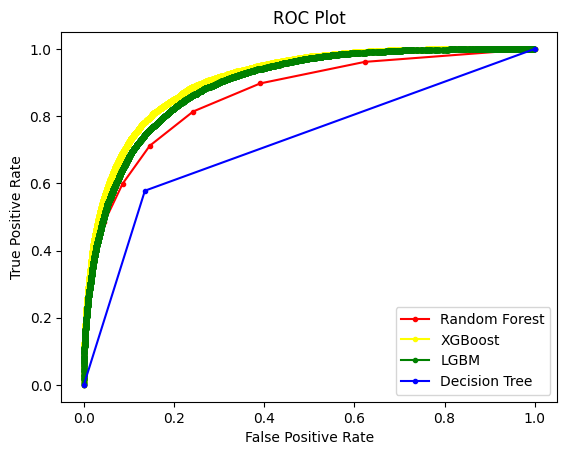

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# -------------------------------
# Function to compute mean ROC
# -------------------------------
def mean_multiclass_roc(fpr_dict, tpr_dict, n_classes):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []

    for fold in fpr_dict.keys():
        tpr_interp_classes = []

        for c in range(n_classes):
            tpr_interp = np.interp(mean_fpr, fpr_dict[fold][c], tpr_dict[fold][c])
            tpr_interp_classes.append(tpr_interp)

        # macro-average over classes
        tprs.append(np.mean(tpr_interp_classes, axis=0))

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = auc(mean_fpr, mean_tpr)

    return mean_fpr, mean_tpr, mean_auc


# -------------------------------
# Number of classes (TE orders)
# -------------------------------
n_classes = 4

# -------------------------------
# Compute mean ROC for all models
# -------------------------------
rf_fpr, rf_tpr, rf_auc = mean_multiclass_roc(rf_order_fpr, rf_order_tpr, n_classes)
xgb_fpr, xgb_tpr, xgb_auc = mean_multiclass_roc(xgb_order_fpr, xgb_order_tpr, n_classes)
lgbm_fpr, lgbm_tpr, lgbm_auc = mean_multiclass_roc(lgbm_order_fpr, lgbm_order_tpr, n_classes)
dt_fpr, dt_tpr, dt_auc = mean_multiclass_roc(dt_order_fpr, dt_order_tpr, n_classes)

# -------------------------------
# Plot combined ROC
# -------------------------------
plt.figure(figsize=(8, 7))

plt.plot(rf_fpr, rf_tpr, color='red',
         label=f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr, color='orange',
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

plt.plot(lgbm_fpr, lgbm_tpr, color='green',
         label=f'LightGBM (AUC = {lgbm_auc:.3f})')

plt.plot(dt_fpr, dt_tpr, color='blue',
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

# Chance line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison of Classifiers (Multiclass TE Order Classification)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.savefig('combined_multiclass_roc.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# ---------------------------------
# MCC results from 10-fold CV
# ---------------------------------
mcc_results = {
    "RF": rf_order_mcc,
    "XGB": xgb_order_mcc,
    "LGBM": lgbm_order_mcc,
    "DT": dt_order_mcc
}

# ---------------------------------
# Paired t-test on MCC only
# ---------------------------------
ttest_rows = []

models = list(mcc_results.keys())

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        m1, m2 = models[i], models[j]

        t_stat, p_value = ttest_rel(
            mcc_results[m1],
            mcc_results[m2]
        )

        ttest_rows.append([
            m1,
            m2,
            np.mean(mcc_results[m1]),
            np.mean(mcc_results[m2]),
            p_value
        ])

# ---------------------------------
# Create table
# ---------------------------------
ttest_mcc_df = pd.DataFrame(
    ttest_rows,
    columns=[
        "Model 1",
        "Model 2",
        "Mean MCC (Model 1)",
        "Mean MCC (Model 2)",
        "p-value"
    ]
)

ttest_mcc_df


In [ ]:
ttest_mcc_df.to_csv(
    "paired_ttest_mcc_multiclass_TE_orders.csv",
    index=False
)
